STP-RRT* algorithm gives the CasADi solver an initial guess for the optimal path

In [156]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import STP_RRTStar
import Dynamic
import numpy as np
import casadi as ca
import matplotlib.patches as patches
from IPython.display import HTML
from scipy.interpolate import splprep, splev
import importlib
import csv
import json
from scipy.interpolate import interp1d
from Camera import Camera
import time

In [157]:
importlib.reload(Dynamic)
from Dynamic import DynamicMap
importlib.reload(STP_RRTStar)
from STP_RRTStar import STP_RRTStar as Rrt

In [158]:
# Importing simulation parameters and generated paths from Jefferson
path_type_string = "ParallelRRT"
scenario_key = "0" 
# 0 was used for time penalty tuning, it also has an initial guess for every path type

# Defender and map info
with open("2D_Comparison_Defender_Map.json", "r") as f:
    defender_data = json.load(f)

# path info
with open("2D_Comparison_Path.json", "r") as f:
    path_data = json.load(f)

'''STP-RRT stuff'''
# Attacker Position
map_size_original = [0, 100, 0, 100] # [-x, x, -y, y]
map_translate = [0, 0]
map_size = [map_size_original[0]-map_translate[0], map_size_original[1]-map_translate[0], map_size_original[2]-map_translate[1], map_size_original[3]-map_translate[1]]
x0_1 = [5, 5, 0] # Start [x, y, t]
x0list = [x0_1] 
xf = [95,95] # Goal [x, y] (t doesn't matter)

# list of camera x and y positions
# cam_x = [3, 6, 7, 5]
# cam_y = [8, 4, 2, 1]
cam_x = defender_data[scenario_key]["x"]
cam_y = defender_data[scenario_key]["y"]


dynamic_obstacle_pos = []

for i in range(len(cam_x)):
    dynamic_obstacle_pos.append([cam_x[i], cam_y[i]])

prox = [0.25, 0.1] # proximity for connection [position, time] 

# General RRT Settings
iter_max = 1000     # maximum number of iterations for the tree
vmax = 2            # max velocity for each point ?
max_time = 1        # max time difference for each point

# Test case
# Vehicle Spec
vehicle = {}
vehicle['v'] = vmax
vehicle['radius'] = 1
t = [10, 1, 500] # [camera_period, camera_increment, some unused variable]

# Map
map_in = {}
# Static Map
map_in['st'] = {}
map_in['st']['size'] = np.array([map_size[0], map_size[1], map_size[2], map_size[3]])
# Single building example
# This is an imaginary cylinder around the camera tripod position
# Collision radius r_cyl = 250 [mm]
# [center_x, center_y, radius]
r_cyl = 1
map_in['st']['n'] = len(cam_x)
for i in range(len(cam_x)):
    map_in['st'][str(i)] = np.array([cam_x[i], cam_y[i], r_cyl])

# map_in['st']['0'] = np.array([cam_x[0], cam_y[0], r_cyl])
# map_in['st']['1'] = np.array([cam_x[1], cam_y[1], r_cyl])
# map_in['st']['2'] = np.array([cam_x[2], cam_y[2], r_cyl])


# Dynamic Map
# This is a continuous function that generates camera FOV coverages
# Input is map_in, and time input t_in
map_in['n'] = t[0] # camera period

# Camera Position
cam_dict = {}
cam_dict['n'] = len(cam_x)
map_in['ncam'] = len(cam_x)
cam_dict['x'] = cam_x
cam_dict['y'] = cam_y

# # Surveillance Pattern Parameters
# tilt_limit = [] #[lower, upper]
# tilt_limit.append([np.deg2rad(0), np.deg2rad(90)])
# tilt_limit.append([np.deg2rad(90), np.deg2rad(180)])
# tilt_limit.append([np.deg2rad(180), np.deg2rad(270)])
# tilt_limit.append([np.deg2rad(225), np.deg2rad(315)])

# init_angles = []
# for i in range(len(cam_x)):
#     init_angles.append((tilt_limit[i][0]+tilt_limit[i][1])/2)
# # init_angles = [(tilt_limit[0][0]+tilt_limit[0][1])/2, (tilt_limit[1][0]+tilt_limit[1][1])/2, (tilt_limit[2][0]+tilt_limit[2][1])/2] 
# # ^^^ Currently setting these to be the midpoints of the angluar range ^^^


# # Camera Spec
# cam_period = t[0]
# cam_increment = t[1]
# cam_dict['spec']['init_angle'] = init_angles
# cam_dict['spec']['bound'] = tilt_limit
# cam_dict['spec']['fov'] = [fov_ang, fov_rng]
# cam_dict['spec']['cam_time'] = [cam_period, cam_increment]

# For Monte Carlo simulation, this is all loaded from Jefferson's file:
cam_dict['spec'] = {}
cam_dict['spec']['init_angle'] = defender_data[scenario_key]["spec"]["init_angle"]
cam_dict['spec']['bound'] = defender_data[scenario_key]["spec"]["bound"]              
cam_dict['spec']['fov'] = defender_data[scenario_key]["spec"]["fov"]
cam_dict['spec']['cam_time'] = defender_data[scenario_key]["spec"]["cam_time"]
cam_dict['spec']['panspeed'] = defender_data[scenario_key]["spec"]["panspeed"]

# Importing fov angle and range from Jefferson's results
fov_ang = cam_dict['spec']['fov'][0]
fov_rng = cam_dict['spec']['fov'][1]


cameras_dict_copilot = []
for i in range(cam_dict['n']):
    cam_x_dict = cam_dict['x'][i]
    cam_y_dict = cam_dict['y'][i]
    lower = cam_dict['spec']['bound'][i][0]
    upper = cam_dict['spec']['bound'][i][1]
    amplitude = 0.5 * (upper - lower)
    center = cam_dict['spec']['init_angle'][i] # ASSUMING THAT INITIAL ANGLE IS CENTER ANGLE
    period = cam_dict['spec']['cam_time'][0]
    frequency = 1 / period  # Use Hz for animation
    init_angle = cam_dict['spec']['init_angle'][i]
    # phase_offset = np.arctan2(init_angle - center, amplitude)
    phase_offset = 0 # Assuming that all cameras start at center of angular range
    panspeed = cam_dict['spec']['panspeed'][i]

    cameras_dict_copilot.append({
        'pos': [cam_x_dict, cam_y_dict],
        'amplitude': amplitude,
        'frequency': frequency,
        'phase': phase_offset,
        'center': center,
        'range': fov_rng,
        'panspeed': panspeed
    })


# Test dynamic map
dmap = DynamicMap(map_in, cam_dict)
map_in['dy'] = dmap

# STP-RRT* Execution parameters
x0 = x0list[0]          # start point
nPartition = 5          # number of trees from the end point
compTimeLimit = 300     # computation time limit

min_dist = np.sqrt((x0_1[0]-xf[0])**2 + (x0_1[1]-xf[1])**2)
min_time = min_dist/vmax

tf0 = min_time                 # lower bound on end time randomization
tfn = 20                # upper bound on end time randomization

# Commenting out the RRT generation because Jefferson already did it
# test_rrt = Rrt(vmax, xf, map_size, vehicle, cam_dict, dmap, max_time)

In [159]:
# No RRT generation in this script. Read results from a file
# success_bool, computation_time, total_path_distance, total_path_time, \
#     success, path, V_start, V_goal, E_start, E_goal = \
#         test_rrt.standard_Parallel_RRT(x0, nPartition, compTimeLimit, tf0, tfn)



<Figure size 5000x5000 with 0 Axes>

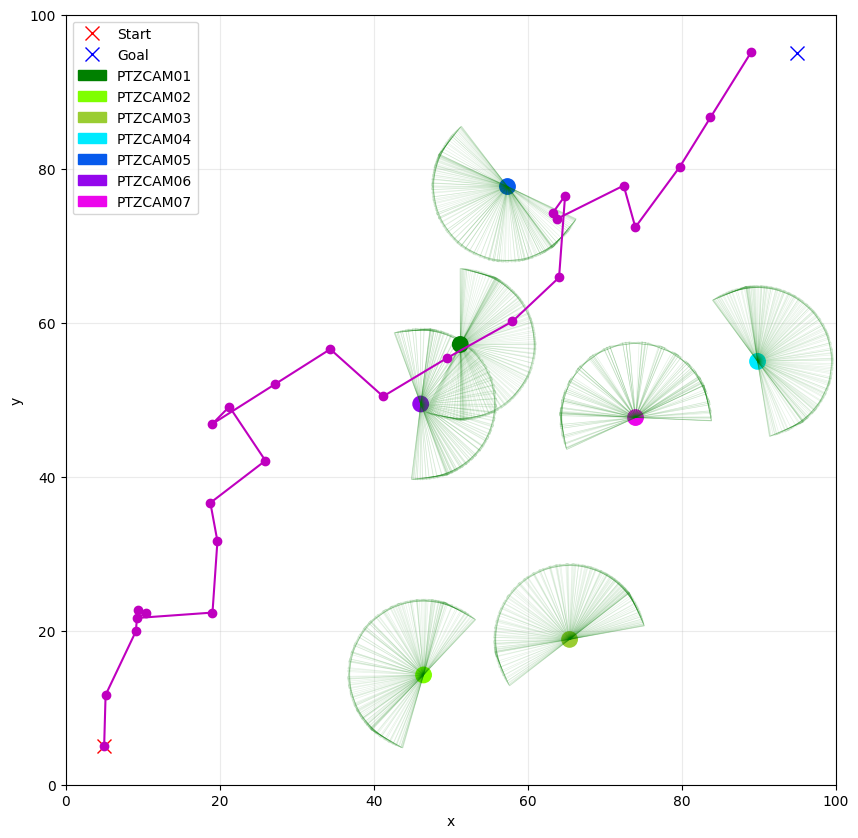

In [160]:
# UNCOMMENT in Jupyter
%matplotlib inline 

if path_type_string == "naive":
    end_point_naive = [xf[0], xf[1], min_time*5]
    path = [x0_1, end_point_naive]
else:
    path = path_data[path_type_string][str(scenario_key)]  # or whichever key you want to use
V_goal = path[-1]
V_start = path[0]

# --------------------------- RRT Visualization ------------------------------------------------#
figure = plt.figure(figsize=(10, 10), dpi = 500)
fig, ax = plt.subplots(figsize=(10, 10))
pointmarker = 10

plt.plot(x0list[0][0], x0list[0][1], 'xr', markersize=pointmarker, label='Start')
plt.plot(xf[0], xf[1], 'xb', markersize=pointmarker, label='Goal')

# Timestamps for fov triangles
num_fov = np.ceil(tfn*5)  # number of time steps (Currently at 5 Hz sampling)
start_time = path[0][2]
end_time = path[len(path)-1][2]
t_fov = np.linspace(start_time, end_time, num_fov+1)

# # helper funciton to pass a camera dictionary with only the fov bounds and initial angle for that particular camera
# def make_single_cam_dict(cam_dict, cam_index):
#     return {
#         'x': [cam_dict['x'][cam_index]],
#         'y': [cam_dict['y'][cam_index]],
#         'n': 1,
#         'spec': {
#             'bound': cam_dict['spec']['bound'][cam_index],
#             'fov': cam_dict['spec']['fov'],
#             'cam_time': cam_dict['spec']['cam_time'],
#             'init_angle': cam_dict['spec']['init_angle'][cam_index]
#         }
#     }


# for t in t_fov:
#     for ii in range(len(cam_x)):
#         # Preprocess cam_dict for this camera
#         cam_dict_single = make_single_cam_dict(cam_dict, ii)

#         # Create a temporary DynamicMap with just one camera
#         temp_map = {
#             'n': cam_dict['spec']['cam_time'][0],  # camera period
#             'ncam': 1,
#             'x': [cam_x[ii]],
#             'y': [cam_y[ii]]
#         }

#         temp_dmap = DynamicMap(temp_map, cam_dict_single)
#         cameras_dmap = temp_dmap.gen_cam(t)

#         cam_i_fov_poly = cameras_dmap['0']['FOV_Poly']  # only one camera

#         cx, cy = cam_i_fov_poly.exterior.xy
#         plt.plot(cx, cy, '-g', alpha=0.1, linewidth=0.5)



# # Old version with issues passing a full list to the dmap
# for t in t_fov:
#     for ii in range(len(cam_x)):
#         cameras_dmap = dmap.gen_cam(ii, t)
#         #ncam = cameras_dmap['n']
#         cam_i_fov_poly = cameras_dmap[str(ii)]['FOV_Poly']
#         cx, cy = cam_i_fov_poly.exterior.xy
#         plt.plot(cx, cy, '-g', alpha=0.1, linewidth=0.5)

for t in t_fov:
    for ii in range(len(cam_x)):
        cameras_dmap = dmap.gen_cam(ii, t)
        cam_i_fov_poly = cameras_dmap[str(ii)]['FOV_Poly']
        cx, cy = cam_i_fov_poly.exterior.xy
        plt.plot(cx, cy, '-g', alpha=0.1, linewidth=0.5)
        
building_alpha = 1
camera_color = ['#008000', '#7FFF00', '#9ACD32', "#00EAFF", "#065AEC", "#9406EC", "#EC06EC", "#EC0694", "#EC8806", "#EC0E06"]
for ii in range(map_in['st']['n']):
    ibuilding = map_in['st'][str(ii)]
    camera_circle = plt.Circle((ibuilding[0], ibuilding[1]), ibuilding[2], color=camera_color[ii], alpha=building_alpha, clip_on=False, label='PTZCAM0'+str(ii+1))
    ax.add_patch(camera_circle)

# Plot RRT

# Ignoring vertex plotting, I only care about the final path
# for vi in V_start:
#     plt.plot(vi[0], vi[1], '.r')
# for i in range(len(V_goal)):
#     for vi in V_goal[str(i)]:
#         plt.plot(vi[0], vi[1], '.b')

# Plot Path
for pi in path:
    plt.plot(pi[0], pi[1], 'om')

for pii in range(len(path)-1):
    p1 = path[pii]
    p2 = path[pii+1]
    plt.plot([p1[0], p2[0]], [p1[1], p2[1]], '-m')


plt.grid(alpha=0.25)
plt.axis('square')
# Plot Limits
plt.xlim(map_size[0], map_size[1])
plt.ylim(map_size[2], map_size[3])
plt.xlabel('x')
plt.ylabel('y')
plt.legend()

plt.show()
# fig.savefig('crazyflie_test_map.png')


CasADi Optimization

In [ ]:
# CasADi

# Cost function: at each time step, take the pointwise probability of detection k(x,t) where x is the
# position and t is the time. 
# P_detection = 1 - P_not_detected
# P_not_detected = (1-k(x1,t1))*(1-k(x2,t2))*(1-k(x3,t3))*...
# P_not_detected = PI(1-k(x_i, t_i))
# log(P_not_detected) = log(PI(1-k(x_i, t_i)))
# log(P_not_detected) = log(1-k(x_1, t_1) + log(1-k(x_2, t_2) + log(1-k(x_3, t_3) + ...
# So, at each time step, take the pointwise detectability, then take the log of it, then add it to the running cost
# CasADi should try to MAXIMIZE this summation of logarithms to minimize the probability of detection

# Once you have the sum of the logarithms, here's how you convert back to a probability of detection:
# log(1-k(x_1, t_1) + log(1-k(x_2, t_2) + log(1-k(x_3, t_3) + ... = log(P_not_detected)
# exp(log(P_not_detected)) = P_not_detected
# P_detected = 1 - P_not_detected


# Gemini alpha calculation:
# alpha ~= 99/range_max^2

tic = time.time()


alpha = 99/(fov_rng**2)#this is the distance decay variable (higher = more decay) (0.1 was decent looking)
k = 100 #this is the steepness of visibility transition (higher = sharper transition)


# New version, uses call to Camera.py to find FOV center:
def calculate_k_value(xi, yi, ti, camera_objects):
    total_cost = 0
    for cam in camera_objects:
        cam_x, cam_y = cam.cam_position()
        phi = cam.get_ctr_theta_t(ti)  # Use Camera.py method

        theta = cam.fov_ang
        dx = xi - cam_x
        dy = yi - cam_y
        dist2 = dx**2 + dy**2
        dist = ca.sqrt(dist2 + 1e-6)

        cos_alpha = (dx * ca.cos(phi) + dy * ca.sin(phi)) / dist
        visibility = 1 / (1 + ca.exp(-k * (cos_alpha - ca.cos(theta / 2))))
        observability = 1 / (1 + alpha * dist2)
        total_cost += visibility * observability
    return total_cost



opti = ca.Opti()

# Set timestamps
N = 2000  # number of time steps (tune this)

# NEW: total travel time T is a decision variable (>= small positive)
T = opti.variable()

# Derived: per-step time (CasADi expression)
dt = T / N

opti.subject_to(T >= 1e-3)  # strictly positive
opti.subject_to(T <= end_time)

start_time = path[0][2]
end_time = path[len(path)-1][2]

# Decision variables
x = opti.variable(N+1)  # UAV x coords
y = opti.variable(N+1)  # UAV y coords

# Initial position constraints
opti.subject_to(x[0] == x0_1[0])
opti.subject_to(y[0] == x0_1[1])
# Final position constraints
opti.subject_to(x[-1] == xf[0])
opti.subject_to(y[-1] == xf[1])

# Map bounds
opti.subject_to(opti.bounded(map_size[0], x, map_size[1]))
opti.subject_to(opti.bounded(map_size[2], y, map_size[3]))

# Max speed constraint
vmax = vehicle['v']
for i in range(N):
    dx = x[i+1] - x[i]
    dy = y[i+1] - y[i]
    opti.subject_to(dx*dx + dy*dy <= (vmax*dt)**2)

# Generating Camera objects
camera_objects = []
for i in range(cam_dict['n']):
    cam_obj = Camera(i, cam_dict, cam_dict['x'][i], cam_dict['y'][i])
    camera_objects.append(cam_obj)

# New cost (I guess maybe it's a "utility"):
log_sum = 0
for i in range(N):
    t_i = start_time + i * dt
    k_value = calculate_k_value(x[i], y[i], t_i, camera_objects) # generating pointwise detectability
    current_log_term = ca.log(1 - k_value)
    log_sum += current_log_term

# Cost function: at each time step, take the pointwise probability of detection k(x,t) where x is the
# position and t is the time. 
# P_detection = 1 - P_not_detected
# P_not_detected = (1-k(x1,t1))*(1-k(x2,t2))*(1-k(x3,t3))*...
# P_not_detected = PI(1-k(x_i, t_i))
# log(P_not_detected) = log(PI(1-k(x_i, t_i)))
# log(P_not_detected) = log(1-k(x_1, t_1) + log(1-k(x_2, t_2) + log(1-k(x_3, t_3) + ...
# So, at each time step, take the pointwise detectability, then take the log of it, then add it to the running cost
# CasADi should try to MAXIMIZE this summation of logarithms to minimize the probability of detection
# So, minimize the negative of the log_sum


# time penalty to encourage shorter time
time_penalty = 0.02*T
# I want this to make the path smoother without affecting the probability of detection
# Looks like 0.01 is a reasonable choice
# 0: 0.383 pd
# 0.01: 0.366
# 0.02: 0.4 pd
# I'm going with that for now ^^

J_total_cost = log_sum - time_penalty # We want to maximize the log sum, so the time penalty should be signed opposite from log_sum

opti.minimize(-J_total_cost) # We want to MAXIMIZE the log sum, so we minimize the negative of the total cost


# Once you have the sum of the logarithms, here's how you convert back to a probability of detection:
# log(1-k(x_1, t_1) + log(1-k(x_2, t_2) + log(1-k(x_3, t_3) + ... = log(P_not_detected)
# exp(log(P_not_detected)) = P_not_detected
# P_detected = 1 - P_not_detected

def interpolate_rrt_path_preserve_speed(rrt_path, num_points):
    """
    Interpolates the original STP-RRT path using time-based interpolation,
    preserving the original speed profile.

    Parameters:
    - rrt_path: list of [x, y, t] points from STP-RRT
    - num_points: number of interpolated points to generate

    Returns:
    - x_interp: list of interpolated x positions
    - y_interp: list of interpolated y positions
    - t_interp: list of interpolated time values
    """
    rrt_array = np.array(rrt_path)
    x = rrt_array[:, 0]
    y = rrt_array[:, 1]
    t = rrt_array[:, 2]

    # Create interpolation functions for x(t) and y(t)
    fx = interp1d(t, x, kind='linear')
    fy = interp1d(t, y, kind='linear')

    # Generate evenly spaced time values
    t_interp = np.linspace(t[0], t[-1], num_points)

    # Interpolate positions
    x_interp = fx(t_interp)
    y_interp = fy(t_interp)

    return x_interp.tolist(), y_interp.tolist(), t_interp.tolist()



# Interpolating RRT initial guess
x_interp, y_interp, t_interp = interpolate_rrt_path_preserve_speed(path, N+1)


# Using time interpolated RRT as the initial guess
opti.set_initial(x, x_interp)
opti.set_initial(y, y_interp)

# (Optional) Provide a reasonable initial guess
# Use your RRT path for x,y and initialize T with its duration, then the solver is free to shrink it.
T_init = float(path[-1][2] - path[0][2])
opti.set_initial(T, T_init)

# CasADi function to calculate detection probability of a path:
# 4. Get the full symbolic decision variable vector (x, y, T)
w_sym = ca.vertcat(x, y, T) 

# 5. this calculates the log sum for a particular path
log_sum_evaluator = ca.Function('physical_cost_evaluator', [w_sym], [log_sum])

# 6. This calculates the time pnalty term for a particular path
penalty_cost_evaluator = ca.Function('penalty_cost_evaluator', [w_sym], [time_penalty])

# Calculating Probability of Detection for initial path:
# Prepare the numerical initial guess vector (w0)
w0 = ca.vertcat(x_interp, y_interp, T_init)

# Evaluate the log sum for the initial path
initial_log_sum_dm = log_sum_evaluator(w0)
initial_log_sum_value = initial_log_sum_dm.full().item()

# Evaluate the Penalty Cost for the initial path
initial_penalty_cost_dm = penalty_cost_evaluator(w0)
initial_penalty_cost_value = initial_penalty_cost_dm.full().item()

# Calculate the inital probability of detection of the path:
# Calculate and Report Results:
initial_P_non_detection = np.exp(initial_log_sum_value)
initial_P_detection = 1 - initial_P_non_detection
initial_total_cost = initial_log_sum_value - initial_penalty_cost_value

# Once you have the sum of the logarithms, here's how you convert back to a probability of detection:
# log(1-k(x_1, t_1) + log(1-k(x_2, t_2) + log(1-k(x_3, t_3) + ... = log(P_not_detected)
# exp(log(P_not_detected)) = P_not_detected
# P_detected = 1 - P_not_detected
# so P_detected = 1 - exp(log_sum)



# Solver options
p_opts = {"expand": True}
s_opts = {
    "max_iter": 3000,
    "tol": 1e-6,
    "acceptable_tol": 1e-4,
    "print_level": 5,
}

opti.solver("ipopt", p_opts, s_opts)

# Solve
try:
    sol = opti.solve()
    x_opt = sol.value(x)
    y_opt = sol.value(y)
    T_opt = float(sol.value(T))
    log_sum_opt = sol.value(log_sum)
except RuntimeError as e:
    print("Solver failed:", e)
    x_opt = opti.debug.value(x)
    y_opt = opti.debug.value(y)
    T_opt = opti.debug.value(T)
    log_sum_opt = opti.debug.value(log_sum)

# Calculating final probability of detection
# Prepare the numerical final guess vector (wf)
wf = ca.vertcat(x_opt, y_opt, T_opt)

# Evaluate the log sum for the final path
final_log_sum_dm = log_sum_evaluator(wf)
final_log_sum_value = final_log_sum_dm.full().item()

# Evaluate the Penalty Cost for the final path
final_penalty_cost_dm = penalty_cost_evaluator(wf)
final_penalty_cost_value = final_penalty_cost_dm.full().item()

# Calculate the inital probability of detection of the path:
# Calculate and Report Results:
final_P_non_detection = np.exp(final_log_sum_value)
final_P_detection = 1 - final_P_non_detection
final_total_cost = final_log_sum_value - final_penalty_cost_value

# Build a numeric time vector for export/animation
t_opt_num = np.linspace(start_time, start_time + T_opt, N+1)

# Final output: list of [x, y, t]
optimized_path = list(zip(x_opt, y_opt, t_opt_num))

toc = time.time() - tic

# print(f"Final log_sum value: {final_log_sum_value:.4f}")
# print(f"Final Time Penalty: {final_penalty_cost_value:.4f}")
# print(f"Final Total Cost (J): {final_total_cost:.4f}")
print(f"Initial Probability of Detection: {initial_P_detection:.4f}")
print(f"Final Probability of Detection: {final_P_detection:.4f}")
print(f"time to calculate: {toc}")

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:        4
Number of nonzeros in inequality constraint Jacobian.:    14004
Number of nonzeros in Lagrangian Hessian.............:    14001

Total number of variables............................:     4003
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:        4
Total number of inequality constraints...............:     6004
        inequality constraints with only lower bounds:        1
   inequality constraints with lower and upper bounds:     4002
        inequality constraints with only upper bounds:     2001

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  5.2148938e+00 1.24e+01 1.96e+00  -1.0 0.00e+00    -  0.00e+00 0.00e+00 

In [162]:
'''Old code here (for safekeeping)'''

# def calculate_k_value(xi, yi, ti, cam_dict):
#     total_cost = 0
#     n_cams = cam_dict['n']
    
#     for i in range(n_cams):

#         cam_x = cam_dict['x'][i]
#         cam_y = cam_dict['y'][i]

#         lower = cam_dict['spec']['bound'][i][0]
#         upper = cam_dict['spec']['bound'][i][1]
#         theta = cam_dict['spec']['fov'][0]

#         period = cam_dict['spec']['cam_time'][0]
#         frequency = 1/period # Camera frequency in Hz
#         init_angle = cam_dict['spec']['init_angle'][i]
        
#         amplitude = 0.5 * (upper - lower)
#         center = 0.5 * (upper + lower)
#         # phase_offset = np.arctan2(init_angle - center, amplitude)
#         phase_offset = 0 # Assuming all cameras start at center of angular range

#         # OLD VERSION: this is using positive angles as counterclockwise
#         # Camera orientation at time t
#         phi = center + amplitude * ca.sin(2 * np.pi * frequency * ti + phase_offset)
        
#         # # Camera orientation at time t (converted to clockwise)
#         # phi_ccw = center + amplitude * ca.sin(2 * np.pi * frequency * ti + phase_offset)
#         # phi = (2 * np.pi - phi_ccw) % (2 * np.pi)

#         # Relative position to UAV
#         dx = xi - cam_x
#         dy = yi - cam_y
#         dist2 = dx**2 + dy**2
#         dist = ca.sqrt(dist2 + 1e-6)

#         # Angle alignment term
#         cos_alpha = (dx * ca.cos(phi) + dy * ca.sin(phi)) / dist

#         # Visibility and distance attenuation
#         visibility = 1 / (1 + ca.exp(-k * (cos_alpha - ca.cos(theta / 2))))
#         observability = 1 / (1 + alpha * dist2)

#         total_cost += visibility * observability

#     return total_cost


# Old way with exposure integral (boooooo)
# total_cost = 0
# for i in range(N):
#     # Midpoint states
#     xm = 0.5*(x[i] + x[i+1])
#     ym = 0.5*(y[i] + y[i+1])

#     # NEW: midpoint time as CasADi expression (no numpy linspace)
#     tm = start_time + (i + 0.5) * dt

#     # Exposure integral (Riemann)
#     total_cost += calculate_k_value(xm, ym, tm, camera_objects) * dt

# # Cost function: integrate camera exposure
# total_cost = 0
# for i in range(N):
#     #dt_i = T[0, i+1] - T[0, i]
#     #dt.append(dt_i)

#     # Midpoint positions & times for integration
#     xm = 0.5 * (x[i] + x[i+1])
#     ym = 0.5 * (y[i] + y[i+1])
#     tm = 0.5 * (t_opt[i] + t_opt[i+1])

#     total_cost += calculate_k_value(xm, ym, tm, cam_dict) * dt

# # Smoothness cost
# lam_smooth = 0  # smoothness weight (tune this)
# smoothness_cost = 0

# for i in range(1, N):  # from 1 to N-1 for second difference
#     ax = (x[i+1] - 2*x[i] + x[i-1]) / (dt**2)
#     ay = (y[i+1] - 2*y[i] + y[i-1]) / (dt**2)
#     smoothness_cost += lam_smooth * (ax**2 + ay**2)*dt
# total_cost += smoothness_cost

# # Soft speed constraint
# for i in range(N):
#     dx = x[i+1] - x[i]
#     dy = y[i+1] - y[i]
#     dist_sq = dx**2 + dy**2
#     speed_penalty = (dist_sq - (speed * dt)**2)**2
#     total_cost += 1e4 * speed_penalty  # weight can be tuned

# # Hard speed constraint
# for i in range(N):
#     dx = x[i+1] - x[i]
#     dy = y[i+1] - y[i]
#     dist_sq = dx**2 + dy**2
    
#     tolerance = 1e-2
#     opti.subject_to(ca.fabs(dist_sq - (speed * dt)**2) <= tolerance)




# def rrt_path_to_constant_speed_guess(rrt_path, N, start_time_g, end_time_g):
#     """
#     Converts RRT path to initial guess points spaced for constant speed
#     determined by path length and total time.

#     Parameters:
#     - rrt_path: array-like shape (M, 2) or (M, 3) (x, y, [t]) points from RRT
#     - N: number of intervals (so guess will have N+1 points)
#     - start_time_g: initial time
#     - end_time_g: final time

#     Returns:
#     - x_guess: list of x positions (N+1)
#     - y_guess: list of y positions (N+1)
#     - t_guess: list of times (N+1), linearly spaced
#     - speed: computed constant speed along path
#     """
#     rrt_path = np.array(rrt_path)
#     positions = rrt_path[:, :2]

#     # Compute cumulative distances along the path
#     deltas = np.diff(positions, axis=0)
#     segment_lengths = np.linalg.norm(deltas, axis=1)
#     cumulative_dist = np.insert(np.cumsum(segment_lengths), 0, 0)

#     total_length = cumulative_dist[-1]
#     total_time = end_time_g - start_time_g

#     # Calculate constant speed as total length / total time
#     speed_for_guess = total_length / total_time

#     # Re-sample points evenly spaced along the path length
#     target_distances = np.linspace(0, total_length, N+1)

#     # Interpolate x and y coordinates at these distances
#     x_guess = np.interp(target_distances, cumulative_dist, positions[:,0])
#     y_guess = np.interp(target_distances, cumulative_dist, positions[:,1])

#     # Linearly spaced times from start to end
#     t_guess = np.linspace(start_time_g, end_time_g, N+1)

#     return x_guess.tolist(), y_guess.tolist(), t_guess.tolist(), speed_for_guess

# def smooth_rrt_path(rrt_path, num_points):
#     """
#     Smooths an RRT path using spline interpolation for x and y,
#     and linear interpolation for time.

#     Parameters:
#     - rrt_path: list of [x, y, t] points
#     - num_points: number of output points (default 51)

#     Returns:
#     - x_smooth: list of smoothed x coordinates
#     - y_smooth: list of smoothed y coordinates
#     - t_smooth: list of linearly interpolated time values
#     """
#     rrt_array = np.array(rrt_path)
#     x = rrt_array[:, 0]
#     y = rrt_array[:, 1]
#     t = rrt_array[:, 2]

#     # Fit spline to x and y
#     tck, u = splprep([x, y], s=1.0)  # s is the smoothing factor

#     # Generate smoothed points
#     u_fine = np.linspace(0, 1, num_points)
#     x_smooth, y_smooth = splev(u_fine, tck)

#     # Linearly interpolate time
#     t_smooth = np.linspace(t[0], t[-1], num_points)

#     return x_smooth.tolist(), y_smooth.tolist(), t_smooth.tolist()

# # Constant speed adjustment
# x_init, y_init, t_init, speed_init = rrt_path_to_constant_speed_guess(path, N, start_time, end_time) # Constant speed RRT path
# rrt_const_speed_path = list(zip(x_init, y_init, t_init)) 

# # Spline interpolation to make it smooth
# x_smooth, y_smooth, t_smooth = smooth_rrt_path(rrt_const_speed_path, N+1)
# rrt_smooth_path = list(zip(x_smooth, y_smooth, t_smooth))



'Old code here (for safekeeping)'

File Export for Path Comparison

In [163]:
# === Save original speed RRT path ===
interpolated_path = list(zip(x_interp, y_interp, t_interp))
with open('rrt_original_path.csv', 'w', newline='') as f_out:
    writer = csv.writer(f_out)
    writer.writerow(['x', 'y', 't'])
    for xi, yi, ti in interpolated_path:
        writer.writerow([xi, yi, ti])

# # === Save constant-speed RRT path ===
# with open('rrt_const_speed_path.csv', 'w', newline='') as f_rrt:
#     writer = csv.writer(f_rrt)
#     writer.writerow(['x', 'y', 't'])
#     for xi, yi, ti in zip(x_init, y_init, t_init):
#         writer.writerow([xi, yi, ti])

# # === Save interpolated (smoothed) RRT path ===
# with open('rrt_smooth_path.csv', 'w', newline='') as f_rrt_smooth:
#     writer = csv.writer(f_rrt_smooth)
#     writer.writerow(['x', 'y', 't'])
#     for xi, yi, ti in rrt_smooth_path:
#         writer.writerow([xi, yi, ti])

# === Save optimized path ===
with open('optimized_path.csv', 'w', newline='') as f_opt:
    writer = csv.writer(f_opt)
    writer.writerow(['x', 'y', 't'])
    for xo, yo, to in zip(x_opt, y_opt, t_opt_num):
        writer.writerow([xo, yo, to])



theta = cam_dict['spec']['fov'][0] # Currently assuming all cameras have the same FOV angle
fov_range = cam_dict['spec']['fov'][1] # Currently assuming all cameras have the same FOV range

# # Save camera parameters to a JSON file
# simulation_parameters = {
#     "theta": float(theta),  # Convert from numpy/casadi type if needed
#     "k": float(k),
#     "alpha": float(alpha),
#     "cameras_dict_copilot": cameras_dict_copilot,
#     "map_size": map_size,
#     "fov_range": fov_range
# }

# Add panspeed to each camera dictionary
for i, cam in enumerate(cameras_dict_copilot):
    cam["panspeed"] = cam_dict["spec"]["panspeed"][i]

# Save camera parameters to a JSON file
simulation_parameters = {
    "theta": float(theta),
    "k": float(k),
    "alpha": float(alpha),
    "cameras_dict_copilot": cameras_dict_copilot,
    "map_size": map_size,
    "fov_range": fov_range,
    "initial_P_detection": initial_P_detection,
    "final_P_detection": final_P_detection
}
with open("simulation_parameters.json", "w") as f:
    json.dump(simulation_parameters, f, indent=4)
print("Simulation parameters saved to simulation_parameters.json.")

Simulation parameters saved to simulation_parameters.json.


Animation Section

In [164]:
# # Animation Cost Functions

# # Camera cost function
# theta = cam_dict['spec']['fov'][0] # Currently assuming all cameras have the same FOV angle

# def camera_cost_np(x, y, t, cam):
#     x_c, y_c = cam['pos']
#     phi = cam['center'] + cam['amplitude'] * np.sin(2 * np.pi * cam['frequency'] * t + cam['phase'])
#     # phi_ccw = cam['center'] + cam['amplitude'] * np.sin(2 * np.pi * cam['frequency'] * t) # Assuming all cameras start at center of angular range
#     # phi = (2 * np.pi - phi_ccw) % (2 * np.pi) # adjusting for clockwise angles as positive

#     dx = x - x_c
#     dy = y - y_c
#     distance_squared = dx**2 + dy**2
#     distance = np.sqrt(distance_squared)
#     distance = np.where(distance == 0, 1e-6, distance)
#     cos_alpha = (dx * np.cos(phi) + dy * np.sin(phi)) / distance
#     visibility = 1 / (1 + np.exp(-k * (cos_alpha - np.cos(theta / 2))))
#     observability = 1 / (1 + alpha * distance_squared)
#     return visibility * observability

# # Total cost function
# def total_cost_np(x, y, t):
#     cost = np.zeros_like(x)
#     for cam in cameras_dict_copilot:
#         cost += camera_cost_np(x, y, t, cam)
#     return cost


# # Recompute exposure cost using optimized path
# exposure_cost_val = 0
# for i in range(len(x_opt) - 1):
#     xm = 0.5 * (x_opt[i] + x_opt[i+1])
#     ym = 0.5 * (y_opt[i] + y_opt[i+1])
#     tm = 0.5 * (t_opt[i] + t_opt[i+1])
    
#     # Sum cost from each camera
#     for cam in cameras_dict_copilot:
#         exposure_cost_val += camera_cost_np(xm, ym, tm, cam) * dt

# # Apply Poisson transformation
# P_detected_val = 1 - np.exp(-exposure_cost_val)

# # Print result
# print("Overall probability of detection (Poisson model):", P_detected_val)


In [165]:



# # Grid for contour plot
# x_vals = np.linspace(map_size[0], map_size[1], 200)
# y_vals = np.linspace(map_size[2], map_size[3], 200)
# X, Y = np.meshgrid(x_vals, y_vals)

# # Set up the figure and axis
# fig, ax = plt.subplots(figsize=(8, 6))
# Z = total_cost_np(X, Y, 0)
# contour = ax.contourf(X, Y, Z, levels=100, cmap='viridis')
# for cam in cameras_dict_copilot:
#     ax.plot(cam['pos'][0], cam['pos'][1], 'ro', label='Camera')
# uav_dot, = ax.plot([], [], 'wo', markersize=6, label='UAV')
# uav_path_line, = ax.plot([], [], 'w--', linewidth=1, label='UAV Path')
# title = ax.set_title(f'Optimized UAV Path, Probability of Detection: {P_detected_val}, (t = 0.00s)')
# plt.colorbar(contour, ax=ax, label='Cost')
# ax.set_xlabel('x')
# ax.set_ylabel('y')
# ax.grid(True)
# ax.legend()


# def update(frame):
#     t = t_opt[frame]
#     Z = total_cost_np(X, Y, t)

#     # Clear previous contour
#     for c in ax.collections:
#         c.remove()

#     # Draw new contour (don't try to access .collections)
#     ax.contourf(X, Y, Z, levels=100, cmap='viridis')

#     # # Replot cameras
#     # for cam in cameras_dict_copilot:
#     #     ax.plot(cam['pos'][0], cam['pos'][1], 'ro')


#     # Remove previous FOV triangles
#     [patch.remove() for patch in ax.patches]

#     for cam in cameras_dict_copilot:
#         x_c, y_c = cam['pos']
#         amplitude = cam['amplitude']
#         frequency = cam['frequency']
#         # phase = cam['phase']
#         phase = 0 # Assuming all cameras start at center of angular range
#         center = cam['center']
#         fov_angle = theta  # total FOV angle in radians
#         fov_range = 2      # how far the camera can see

#         # Compute current pan angle
#         phi = center + amplitude * np.sin(2 * np.pi * frequency * t + phase)
        
#         # phi_ccw = center + amplitude * np.sin(2 * np.pi * frequency * t + phase)
#         # phi = (2 * np.pi - phi_ccw) % (2 * np.pi) # adjusting to make positive angles clockwise

#         # Compute left and right edge angles
#         left_angle = phi - fov_angle / 2
#         right_angle = phi + fov_angle / 2

#         # Compute triangle points
#         left_point = (x_c + fov_range * np.cos(left_angle), y_c + fov_range * np.sin(left_angle))
#         right_point = (x_c + fov_range * np.cos(right_angle), y_c + fov_range * np.sin(right_angle))

#         # Create triangle patch
#         triangle = patches.Polygon(
#             [[x_c, y_c], left_point, right_point],
#             closed=True,
#             color='red',
#             alpha=0.2
#         )
#         ax.add_patch(triangle)

#         # Draw camera position
#         ax.plot(x_c, y_c, 'ro')



#     # Update UAV path and dot
#     path_x = x_opt[:frame+1]
#     path_y = y_opt[:frame+1]
#     uav_path_line.set_data(path_x, path_y)
#     uav_dot.set_data([x_opt[frame]], [y_opt[frame]])
#     title.set_text(f'Optimized UAV Path, Probability of Detection: {P_detected_val:.3}, (t = {t:.2f}s)')

#     # Return only the updated artists
#     return [uav_path_line, uav_dot, title]

# # Create animation
# if x_opt is None or y_opt is None or len(x_opt) == 0 or len(y_opt) == 0:
#     raise ValueError("Optimization failed or returned empty path. Cannot animate.")



# # Create animation


# # # Short version
# # start_frame = 0 # Frame index of the start frame
# # end_frame = int(np.ceil(N/10)) # Frame index of the end frame

# # Decent version (takes a long time to render)
# start_frame = 0 # Frame index of the start frame
# end_frame = N # Frame index of the end frame

# # # Only animating every 8th frame (7.5 FPS) ~ 120 sec to render
# # frame_indices = list(range(start_frame, end_frame, 8)) 

# # Only animating every 16th frame (3.25 FPS) ~ 60 sec to render
# frame_indices = list(range(start_frame, end_frame, 16)) 

# anim_time = t_opt[end_frame] - t_opt[start_frame]  
# interval = (anim_time / len(frame_indices)) * 1000  # milliseconds per frame

# anim = animation.FuncAnimation(fig, update, frames=frame_indices, interval=interval, blit=False)

# # # Show plot
# # plt.show()

# # UNCOMMENT in Jupyter
# HTML(anim.to_jshtml())